# Simple Linear Regression
Predicting **Height (Inches)** from **Weight (Pounds)** using the SOCR Height-Weight dataset.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
%matplotlib inline

## 2. Load & Explore Data

In [2]:
df = pd.read_csv('SOCR-HeightWeight.csv')
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [3]:
# Statistical summary
df.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


In [4]:
# Check for missing values
df.isnull().sum()

Index             0
Height(Inches)    0
Weight(Pounds)    0
dtype: int64

## 3. Data Visualization

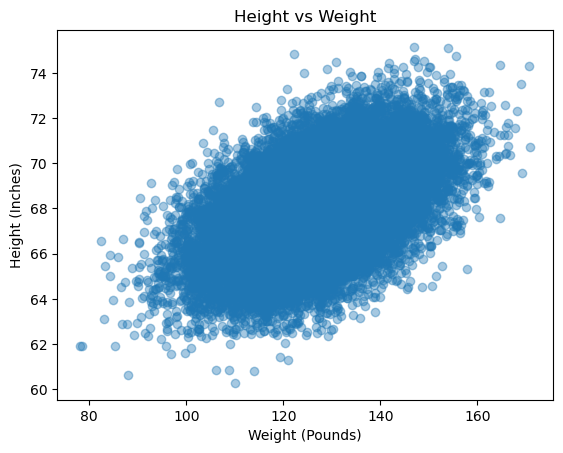

In [5]:
plt.scatter(df['Weight(Pounds)'], df['Height(Inches)'], alpha=0.4)
plt.xlabel('Weight (Pounds)')
plt.ylabel('Height (Inches)')
plt.title('Height vs Weight')
plt.show()

## 4. Feature Selection
- **X** (independent feature): Weight (Pounds)
- **Y** (dependent feature): Height (Inches)

In [6]:
X = df[['Weight(Pounds)']]  # independent feature
Y = df['Height(Inches)']     # dependent feature

## 5. Train-Test Split
80 % of the data is used for training, 20 % for testing.

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)
print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 20000
Test samples     : 5000


## 6. Train the Model
> **Note:** `StandardScaler` is **not needed** for Ordinary Least Squares (OLS) Linear Regression.  
> Unlike gradient-descent-based models, OLS finds the exact solution analytically, so feature scaling does not affect the result.

In [8]:
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 7. Model Coefficients

In [9]:
print(f'Coefficient (slope) : {regressor.coef_[0]:.4f}')
print(f'Intercept           : {regressor.intercept_:.4f}')

Coefficient (slope) : 0.0817
Intercept           : 57.6096


## 8. Regression Line Visualization

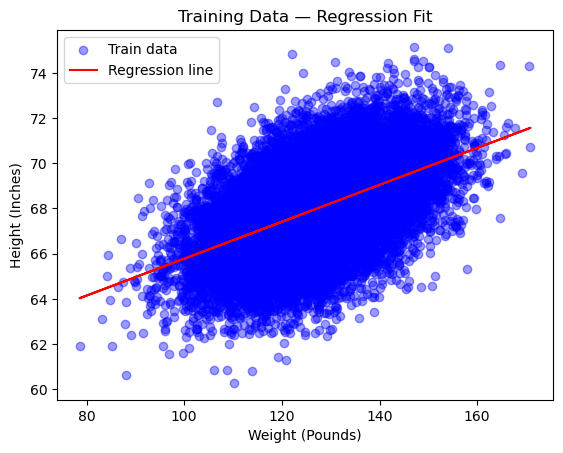

In [10]:
# Training data
plt.scatter(X_train, Y_train, color='blue', alpha=0.4, label='Train data')
plt.plot(X_train, regressor.predict(X_train), color='red', label='Regression line')
plt.xlabel('Weight (Pounds)')
plt.ylabel('Height (Inches)')
plt.title('Training Data — Regression Fit')
plt.legend()
plt.show()

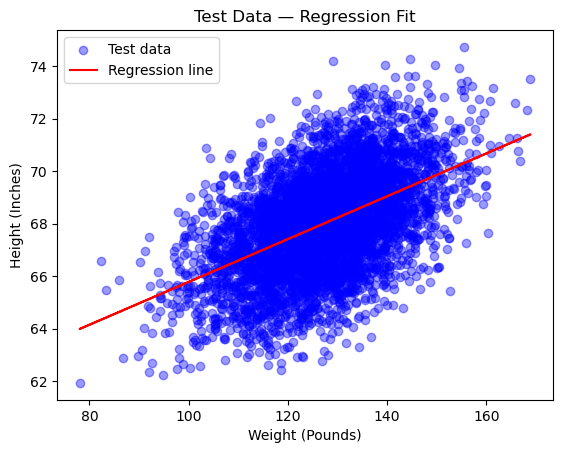

In [11]:
# Test data
plt.scatter(X_test, Y_test, color='blue', alpha=0.4, label='Test data')
plt.plot(X_test, regressor.predict(X_test), color='red', label='Regression line')
plt.xlabel('Weight (Pounds)')
plt.ylabel('Height (Inches)')
plt.title('Test Data — Regression Fit')
plt.legend()
plt.show()

## 9. Performance Metrics

| Metric | Formula |
|---|---|
| **MSE** | mean((y − ŷ)²) |
| **MAE** | mean(\|y − ŷ\|) |
| **RMSE** | √MSE |
| **R²** | 1 − SSR / SST |
| **Adjusted R²** | 1 − [(1 − R²)(n − 1) / (n − k − 1)] |

In [12]:
Y_pred_test = regressor.predict(X_test)

mse    = mean_squared_error(Y_test, Y_pred_test)
mae    = mean_absolute_error(Y_test, Y_pred_test)
rmse   = np.sqrt(mse)
r2     = r2_score(Y_test, Y_pred_test)
n, k   = len(Y_test), X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f'MSE         : {mse:.4f}')
print(f'MAE         : {mae:.4f}')
print(f'RMSE        : {rmse:.4f}')
print(f'R²          : {r2:.4f}')
print(f'Adjusted R² : {adj_r2:.4f}')

MSE         : 2.7250
MAE         : 1.3163
RMSE        : 1.6507
R²          : 0.2606
Adjusted R² : 0.2604


## 10. Cross-Validation
A single train/test split can be lucky or unlucky.  
**5-fold cross-validation** splits the data into 5 parts, trains on 4 and tests on 1 — five times — giving a more reliable performance estimate.

In [13]:
cv_scores = cross_val_score(regressor, X, Y, cv=5, scoring='r2')

print(f'CV R² scores : {cv_scores.round(4)}')
print(f'Mean R²      : {cv_scores.mean():.4f}')
print(f'Std R²       : {cv_scores.std():.4f}')

CV R² scores : [0.2662 0.2517 0.2521 0.233  0.2587]
Mean R²      : 0.2523
Std R²       : 0.0110


## 11. Residual Analysis
Residuals = actual − predicted. A good model should show:
- A **bell-shaped (normal) distribution** of residuals
- **No clear pattern** in the Residuals vs Predicted plot (random scatter around zero)

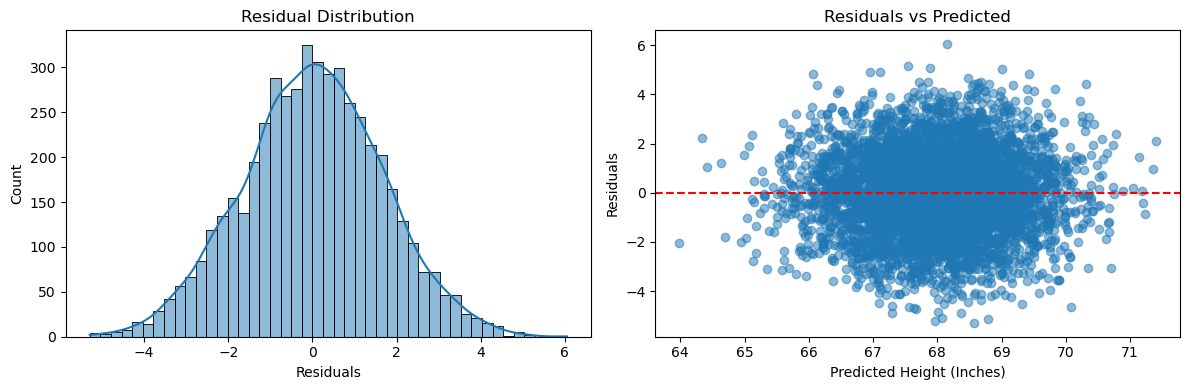

In [14]:
residuals = Y_test - Y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of residuals
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residuals')

# Residuals vs Predicted
axes[1].scatter(Y_pred_test, residuals, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Height (Inches)')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 12. Predict for a New Data Point

In [15]:
new_weight = 150  # pounds
predicted_height = regressor.predict([[new_weight]])[0]
print(f'Predicted height for weight {new_weight} lbs : {predicted_height:.2f} inches')

Predicted height for weight 150 lbs : 69.86 inches


c:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
